<a href="https://colab.research.google.com/github/InderjeetM/squats-tracking-pipeline-project/blob/main/pipeline%2Cvector_fit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q -U google-generativeai mediapipe opencv-python-headless

import cv2
import mediapipe as mp
import numpy as np
import google.generativeai as genai
import sqlite3
import datetime
from google.colab import userdata

try:
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY2')
    genai.configure(api_key=GOOGLE_API_KEY)
    model = genai.GenerativeModel('gemini-2.5-flash')
    print("Environment Ready! Gemini 2.5 is connected.")
except Exception as e:
    print(f"Error: {e}. Ensure 'GEMINI_API_KEY2' is toggled ON in Secrets.")

Environment Ready! Gemini 2.5 is connected.


In [4]:
from google.colab import files

print("Click below and select one or more workout videos (hold Ctrl or Cmd to pick multiple).")
uploaded = files.upload()

video_list = list(uploaded.keys())
print(f"Uploaded {len(video_list)} video(s):")
for v in video_list:
    print(f" - {v}")

Click below and select one or more workout videos (hold Ctrl or Cmd to pick multiple).


Saving Screenrecording_20260706_133256.mp4 to Screenrecording_20260706_133256.mp4
Saving video_20260706_144514_edit.mp4 to video_20260706_144514_edit.mp4
Uploaded 2 video(s):
 - Screenrecording_20260706_133256.mp4
 - video_20260706_144514_edit.mp4


In [5]:
def get_llm_coaching(exercise_name, joint_angle, phase):
    if joint_angle >= 100:
        depth_note = f"{joint_angle} degrees, which is too shallow, needs to go lower"
    else:
        depth_note = f"{joint_angle} degrees, which is good depth"

    prompt = f"""
    Context: You are a professional gym coach.
    Data: Exercise: {exercise_name}, Joint: Knee, Angle: {joint_angle} degrees, Phase: {phase}.
    Goal: In a deep squat, the knee angle should be under 100 degrees.
    Observation: The user's angle is {depth_note}.
    Task: Provide one short, high-energy coaching cue based on this specific observation.
    """
    try:
        response = model.generate_content(prompt)
        return response.text.strip()
    except Exception as e:
        return f"Coach is busy: {str(e)}"

print(f"Sample Coach Tip: {get_llm_coaching('Squat', 115, 'bottom')}")

Sample Coach Tip: **"Ass to grass!"**


In [6]:
def calculate_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)

    if angle > 180.0:
        angle = 360 - angle

    return angle

print("Geometry Engine Loaded!")

Geometry Engine Loaded!


In [12]:
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

!wget -q -O pose_landmarker.task -c https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/1/pose_landmarker_heavy.task
base_options = python.BaseOptions(model_asset_path='pose_landmarker.task')

def create_landmarker():
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        running_mode=vision.RunningMode.VIDEO,
        num_poses=1,
        min_pose_detection_confidence=0.5,
        min_pose_presence_confidence=0.5,
        min_tracking_confidence=0.5
    )
    return vision.PoseLandmarker.create_from_options(options)

print("AI Trainer Vision Engine: READY (fresh landmarker created per video)")

AI Trainer Vision Engine: READY (fresh landmarker created per video)


In [13]:
conn = sqlite3.connect('squat_data.db')
cursor = conn.cursor()

cursor.execute('''
CREATE TABLE IF NOT EXISTS squat_sessions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    filename TEXT,
    processed_on TEXT,
    min_knee_angle REAL,
    depth_result TEXT,
    coach_feedback TEXT
)
''')
conn.commit()

print("Database ready: squat_data.db")

Database ready: squat_data.db


In [14]:
def process_squat_video(video_path):
    output_path = f"analyzed_{video_path}"

    landmarker = create_landmarker()  # fresh instance, timestamps start clean

    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    frame_index = 0
    min_knee_angle = 180

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int((frame_index / fps) * 1000)
        result = landmarker.detect_for_video(mp_image, timestamp_ms)

        if result.pose_landmarks:
            landmarks = result.pose_landmarks[0]
            hip = [landmarks[23].x * width, landmarks[23].y * height]
            knee = [landmarks[25].x * width, landmarks[25].y * height]
            ankle = [landmarks[27].x * width, landmarks[27].y * height]

            knee_angle = calculate_angle(hip, knee, ankle)
            if knee_angle < min_knee_angle:
                min_knee_angle = knee_angle

            cv2.circle(frame, (int(hip[0]), int(hip[1])), 6, (0, 255, 0), -1)
            cv2.circle(frame, (int(knee[0]), int(knee[1])), 6, (0, 255, 0), -1)
            cv2.circle(frame, (int(ankle[0]), int(ankle[1])), 6, (0, 255, 0), -1)
            cv2.line(frame, (int(hip[0]), int(hip[1])), (int(knee[0]), int(knee[1])), (255, 255, 255), 2)
            cv2.line(frame, (int(knee[0]), int(knee[1])), (int(ankle[0]), int(ankle[1])), (255, 255, 255), 2)
            cv2.putText(frame, f"Knee angle: {int(knee_angle)} deg",
                        (int(knee[0]) + 10, int(knee[1])),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        out.write(frame)
        frame_index += 1

    cap.release()
    out.release()
    landmarker.close()  # release this video's detector cleanly

    if min_knee_angle < 100:
        depth_result = "GOOD DEPTH"
    else:
        depth_result = "NOT DEEP ENOUGH"

    coaching_tip = get_llm_coaching('Squat', int(min_knee_angle), 'bottom')

    conn_local = sqlite3.connect('squat_data.db')
    cursor_local = conn_local.cursor()
    cursor_local.execute('''
        INSERT INTO squat_sessions (filename, processed_on, min_knee_angle, depth_result, coach_feedback)
        VALUES (?, ?, ?, ?, ?)
    ''', (video_path, str(datetime.datetime.now()), min_knee_angle, depth_result, coaching_tip))
    conn_local.commit()
    conn_local.close()

    return {
        "filename": video_path,
        "output_video": output_path,
        "min_knee_angle": min_knee_angle,
        "depth_result": depth_result,
        "coach_feedback": coaching_tip
    }

print("Pipeline function ready.")

Pipeline function ready.


In [15]:
all_results = []

for video_file in video_list:
    print(f"\nProcessing: {video_file} ...")
    try:
        result = process_squat_video(video_file)
        all_results.append(result)

        print("="*50)
        print(f"Video: {result['filename']}")
        print(f"Deepest knee angle: {int(result['min_knee_angle'])} degrees")
        print(f"Depth check: {result['depth_result']}")
        print(f"Coach feedback: {result['coach_feedback']}")
        print("="*50)
    except Exception as e:
        print(f"FAILED on {video_file}: {e}")
        print("Skipping to next video.")

print(f"\nDone. {len(all_results)} out of {len(video_list)} video(s) processed successfully.")


Processing: Screenrecording_20260706_133256.mp4 ...
Video: Screenrecording_20260706_133256.mp4
Deepest knee angle: 55 degrees
Depth check: GOOD DEPTH
Coach feedback: Boom! Perfect depth!

Processing: video_20260706_144514_edit.mp4 ...
Video: video_20260706_144514_edit.mp4
Deepest knee angle: 44 degrees
Depth check: GOOD DEPTH
Coach feedback: **"CRUSHED IT! DRIVE UP!"**

Done. 2 out of 2 video(s) processed successfully.


All sessions recorded so far:


,filename,processed_on,min_knee_angle,depth_result
0,Screenrecording_20260706_133256.mp4,2026-07-06 09:31:20.746793,55.262746,GOOD DEPTH
1,Screenrecording_20260706_133256.mp4,2026-07-06 09:40:42.932491,55.262746,GOOD DEPTH
2,video_20260706_144514_edit.mp4,2026-07-06 09:41:39.446349,44.508069,GOOD DEPTH


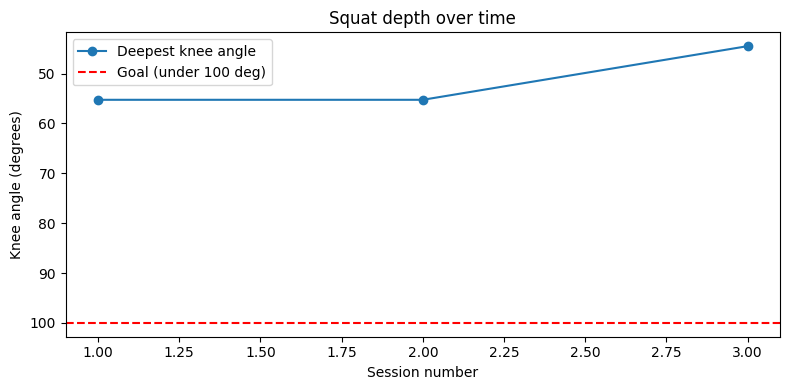

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('squat_data.db')
df = pd.read_sql_query("SELECT * FROM squat_sessions ORDER BY id", conn)
conn.close()

print("All sessions recorded so far:")
display(df[['filename', 'processed_on', 'min_knee_angle', 'depth_result']])

plt.figure(figsize=(8, 4))
plt.plot(df['id'], df['min_knee_angle'], marker='o', label='Deepest knee angle')
plt.axhline(y=100, color='red', linestyle='--', label='Goal (under 100 deg)')
plt.xlabel('Session number')
plt.ylabel('Knee angle (degrees)')
plt.title('Squat depth over time')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
from google.colab import files

files.download('squat_data.db')

for result in all_results:
    files.download(result['output_video'])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>